# SMS Spam Classification with a Neural Network Built from Scratch

**Machine Learning — text-analysis assignment**

## Part 1 — Introduction

### Students

| Student (first name + initial) | ID (last 4 digits) |
|---|---|
| Adir B. (אדיר ב׳) | 7727 |
| Liav W. (ליאב ו׳) | 6898 |

### AI assistants we used

We used **Claude Code (Anthropic, model Claude Fable 5)** as a pair programmer throughout the project.
The full, dated prompt log with links is in [`docs/prompts-log.md`](../docs/prompts-log.md); in short:

| What we asked for | Examples of prompts | Conversation |
|---|---|---|
| Reading the assignment, choosing a dataset that ships a train/test split, planning the work | "we made the decisions and downloaded the dataset, lets continue" · "how can i pick one thats already split" | [session link](https://claude.ai/code/session_019XxZC9ESBsXSmwJUA5PudP) |
| Writing the design spec and implementation plan, then the code and tests, with us reviewing each step | "approved, write the plan and start" | same session |

Everything the assistant produced was read, run and tested by us; the learning algorithm in `src/ann.py`
is verified by a numerical gradient check (Part 3) and a suite of 100+ unit tests (`tests/`).

### The learning problem

**Binary text classification.** Given the text of an SMS message, predict whether it is **spam**
(unsolicited advertising / scams — the positive class) or **not spam** (a normal personal message).
The motivation is the classic spam filter: catch as much spam as possible without hiding real messages
from the user. Because both error types matter and the classes are imbalanced, the quality metric
prescribed by the assignment for binary problems is the **F1 score of the positive class (Spam)**.

### The dataset

* Kaggle: **E-Mail classification NLP** — <https://www.kaggle.com/datasets/datatattle/email-classification-nlp>
  (despite the title, the rows are SMS messages from the well-known SMS Spam Collection).
* Kaggle ships **two files**, and we use them exactly as given — we never re-split, shuffle or de-duplicate:
  `SMS_train.csv` (957 messages) for everything up to and including model selection, and
  `SMS_test.csv` (125 messages), which is opened only in Part 5.
* Columns: `S. No.` (row number), `Message_body` (the text), `Label` ∈ {`Spam`, `Non-Spam`}.
* The files are encoded in Windows-1252 (the `£` sign is byte `0xA3`), so they are read with `encoding="cp1252"`.

**Reproducing this notebook.** Everything below is already executed and its outputs are committed, so nothing
has to be run to read it. To re-run: clone <https://github.com/AdirBuskila/ml-sms-spam-ann>, install
`requirements.txt` (Python 3.13), and run this notebook from inside the repository — it imports the `src/`
package and reads `data/raw/`. A full top-to-bottom run takes about half a minute on a laptop; the unit tests
run with `python -m pytest`.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# make `src` importable whether the notebook is run from notebooks/ or from the repo root
ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data import LABEL_NAMES, LABELS, load_test_df, load_train_df, split_xy
from src.features import HANDCRAFTED_NAMES, FeaturePipeline, TfidfFeaturizer, handcrafted_features, tokenize
from src.ann import NeuralNetwork, gradient_check
from src.metrics import accuracy, confusion_matrix, f1_score, precision, recall
from src.cv import cross_validate, run_grid, stratified_kfold_indices

SEED = 42
pd.set_option("display.max_colwidth", 110)
plt.rcParams["figure.dpi"] = 110
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.5.2 | pandas 3.0.5


### Loading the train set and the test set — as provided

`load_train_df()` / `load_test_df()` read the two CSV files that Kaggle ships (see `src/data.py`).
`split_xy` turns the `Label` column into `y = 1` for **Spam** and `y = 0` for **Non-Spam**.

In [2]:
train_df = load_train_df()
test_df = load_test_df()
train_texts, y_train = split_xy(train_df)
test_texts, y_test = split_xy(test_df)

print(f"train: {train_df.shape[0]} rows   test: {test_df.shape[0]} rows")
print("first 5 rows of the TRAIN set:")
train_df.head()

train: 957 rows   test: 125 rows
first 5 rows of the TRAIN set:


,S. No.,Message_body,Label
0,1,Rofl. Its true to its name,Non-Spam
1,2,The guy did some bitching but I acted like i'd be interested in buying something else next week and he gav...,Non-Spam
2,3,"Pity, * was in mood for that. So...any other suggestions?",Non-Spam
3,4,Will ü b going to esplanade fr home?,Non-Spam
4,5,"This is the 2nd time we have tried 2 contact u. U have won the £750 Pound prize. 2 claim is easy, call 087...",Spam


In [3]:
print("first 5 rows of the TEST set:")
test_df.head()

first 5 rows of the TEST set:


,S. No.,Message_body,Label
0,1,"UpgrdCentre Orange customer, you may now claim your FREE CAMERA PHONE upgrade for your loyalty. Call now o...",Spam
1,2,"Loan for any purpose £500 - £75,000. Homeowners + Tenants welcome. Have you been previously refused? We ca...",Spam
2,3,Congrats! Nokia 3650 video camera phone is your Call 09066382422 Calls cost 150ppm Ave call 3mins vary fro...,Spam
3,4,URGENT! Your Mobile number has been awarded with a £2000 prize GUARANTEED. Call 09058094455 from land line...,Spam
4,5,Someone has contacted our dating service and entered your phone because they fancy you! To find out who it...,Spam


,train,test
Label,,
Non-Spam,835,49
Spam,122,76
total,957,125


spam share: train 12.7%   test 60.8%


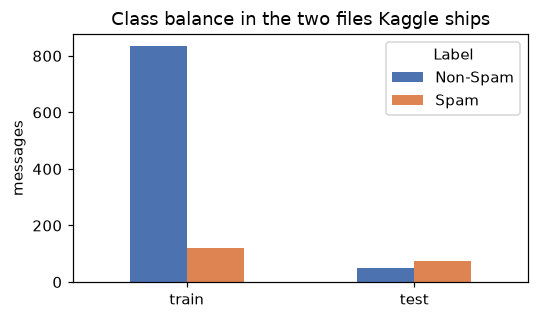

In [4]:
balance = pd.DataFrame({
    "train": train_df["Label"].value_counts(),
    "test": test_df["Label"].value_counts(),
}).reindex(["Non-Spam", "Spam"])
balance.loc["total"] = balance.sum()
display(balance)
print(f"spam share: train {y_train.mean():.1%}   test {y_test.mean():.1%}")

fig, ax = plt.subplots(figsize=(5, 3))
balance.loc[["Non-Spam", "Spam"]].T.plot.bar(ax=ax, rot=0, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("messages")
ax.set_title("Class balance in the two files Kaggle ships")
plt.tight_layout()
plt.show()

Two things to notice, both of which we come back to later:

1. **The training set is spam-minority (12.7 %) while the test set is spam-majority (60.8 %).** The test file
   is also sorted with its spam messages first, which is why `test_df.head()` shows only spam. Our model has
   no notion of row order, so this is harmless — but it means accuracy on the test set would be a poor
   summary, and the F1 score on the Spam class is the right thing to look at.
2. From here until Part 5, **`test_texts` / `y_test` are not used for anything except showing how the
   feature pipeline transforms a few test messages** (Part 2, as the assignment asks). All decisions —
   vocabulary, feature scaling, hyperparameters — are made from the training set alone, using
   cross-validation inside it.

## Part 2 — Feature engineering

A neural network needs numbers, so every message is turned into one fixed-length vector. We build it from
two blocks, both implemented by hand in `src/features.py`:

### 2.1 Tokenisation with placeholders
`tokenize()` lower-cases the text, replaces every **URL** by `__url__`, every run of **7+ digits** (a phone
number, spaces allowed) by `__phone__` and every other **number** by `__num__`, then splits on anything that is
not a letter/digit and drops 1-character tokens.
*Why:* spam almost always contains *some* phone number, *some* price or *some* link, but rarely the same one
twice. With placeholders the model can learn "contains a phone number" from a handful of examples instead of
having to memorise each number.

### 2.2 TF-IDF bag of words
For every token in a vocabulary learned **from the training messages only** (tokens that appear in at least
2 training messages, at most the 2 000 most frequent) we compute

$$\text{tf-idf}(t, m) = \text{tf}(t, m)\cdot\Big(\ln\frac{1+N}{1+\text{df}(t)} + 1\Big),$$

where tf is the count of token *t* in message *m*, *N* the number of training messages and df(*t*) the number
of training messages containing *t*. Each message vector is then L2-normalised.
*Why:* tf captures what the message talks about; idf down-weights tokens that appear everywhere ("to", "the")
and up-weights rare, discriminative ones ("prize", "claim"); normalisation stops long messages from
dominating simply because they contain more words.

### 2.3 Seven handcrafted cues (extra feature engineering)
`handcrafted_features()` adds message length in characters and words, the number of digits, the share of
upper-case letters, the number of `!`, and two flags: *contains a currency symbol* and *contains a URL or a
phone number*. These are standardised (z-scored) with means and standard deviations computed on the training
set. *Why:* they capture the *style* of spam — long, shouting, full of numbers and calls to action — which a
bag of words only sees indirectly. Whether they actually help is tested as a hyperparameter in Part 4.

`FeaturePipeline` glues the blocks together: `fit(texts)` learns vocabulary, idf, means and stds from the
training texts; `transform(texts)` applies them to any texts.

In [5]:
pipe = FeaturePipeline(max_features=2000, min_df=2, use_extra=True).fit(train_texts)
X_train = pipe.transform(train_texts)
print(f"vocabulary size: {len(pipe.tfidf_.vocabulary_)}   handcrafted: {len(HANDCRAFTED_NAMES)}   "
      f"total features: {pipe.n_features_}   X_train: {X_train.shape} {X_train.dtype}")
print("a few vocabulary entries:", pipe.tfidf_.feature_names_[:8], "...", pipe.tfidf_.feature_names_[-8:])

vocabulary size: 1142   handcrafted: 7   total features: 1149   X_train: (957, 1149) float32


a few vocabulary entries: ['__num__', '__phone__', '__url__', 'able', 'about', 'abt', 'access', 'account'] ... ['you', 'your', 'yours', 'yourself', 'yr', 'yrs', 'yup', 'zed']


### The transformation on concrete examples

Three training messages and three test messages. The pipeline was fitted on the training set only; running
test messages *through* it uses no test information — it is exactly what happens at prediction time.

In [6]:
def show_pipeline(texts, labels, title):
    print("=" * 100)
    print(title)
    for text, label in zip(texts, labels):
        print("-" * 100)
        print(f"[{LABEL_NAMES[int(label)]}]  {text}")
        print("  tokens         :", tokenize(text))
        print("  top tf-idf     :", [(t, round(w, 3)) for t, w in pipe.tfidf_.explain(text, k=6)])
        raw = handcrafted_features([text])[0]
        scaled = pipe.scaler_.transform([raw])[0]
        print("  handcrafted    :", {n: round(float(v), 2) for n, v in zip(HANDCRAFTED_NAMES, raw)})
        print("  standardised   :", {n: round(float(v), 2) for n, v in zip(HANDCRAFTED_NAMES, scaled)})
        vec = pipe.transform([text])[0]
        print(f"  feature vector : shape {vec.shape}, {np.count_nonzero(vec)} non-zero entries")

# pick examples by rule so the choice is transparent: a spam with a price, a spam with a link, a longer ham
def first_index(texts, labels, label, predicate):
    return next(i for i, (t, l) in enumerate(zip(texts, labels)) if l == label and predicate(t))

train_examples = [
    first_index(train_texts, y_train, 1, lambda t: "£" in t),
    first_index(train_texts, y_train, 1, lambda t: "www" in t.lower() or "http" in t.lower()),
    first_index(train_texts, y_train, 0, lambda t: len(t) > 60),
]
test_examples = [
    first_index(test_texts, y_test, 1, lambda t: "£" in t),
    first_index(test_texts, y_test, 0, lambda t: True),
    first_index(test_texts, y_test, 0, lambda t: len(t) > 60),
]
print("train example indices:", train_examples, "  test example indices:", test_examples)
show_pipeline([train_texts[i] for i in train_examples], y_train[train_examples], "TRAIN examples")
show_pipeline([test_texts[i] for i in test_examples], y_test[test_examples], "TEST examples")

train example indices:

 [4, 73, 1]   test example indices: [1, 66, 68]
TRAIN examples
----------------------------------------------------------------------------------------------------
[Spam]  This is the 2nd time we have tried 2 contact u. U have won the £750 Pound prize. 2 claim is easy, call 087187272008 NOW1! Only 10p per minute. BT-national-rate.
  tokens         : ['this', 'is', 'the', '__num__', 'nd', 'time', 'we', 'have', 'tried', '__num__', 'contact', 'have', 'won', 'the', '__num__', 'pound', 'prize', '__num__', 'claim', 'is', 'easy', 'call', '__phone__', 'now', '__num__', 'only', '__num__', 'per', 'minute', 'bt', 'national', 'rate']
  top tf-idf     : [('__num__', 0.486), ('have', 0.233), ('pound', 0.232), ('minute', 0.222), ('national', 0.222), ('is', 0.211)]
  handcrafted    : {'n_chars': 160.0, 'n_words': 30.0, 'n_digits': 21.0, 'upper_ratio': 0.09, 'n_exclaim': 1.0, 'has_currency': 1.0, 'has_url_or_phone': 1.0}
  standardised   : {'n_chars': 1.47, 'n_words': 1.39, 'n_digits': 3.06, 'upper_rat

## Part 3 — The learning algorithm: a neural network written from scratch

`src/ann.py` implements a **multi-layer perceptron** (feed-forward neural network) in plain NumPy — no
scikit-learn, no PyTorch. It exposes the usual interface: `NeuralNetwork(...)`, `fit(X, y)`, `predict(X)`,
`predict_proba(X)`.

### How it works

**Architecture.** The input vector $x \in \mathbb{R}^d$ passes through zero or more hidden layers and one
output unit:

$$a^{(0)} = x,\qquad z^{(l)} = a^{(l-1)} W^{(l)} + b^{(l)},\qquad a^{(l)} = g\big(z^{(l)}\big),\qquad
\hat{p} = \sigma\big(z^{(L)}\big) = \frac{1}{1+e^{-z^{(L)}}} .$$

$g$ is the hidden activation (`relu`, `tanh` or `sigmoid` — a hyperparameter) and $\hat p$ is the predicted
probability of spam. With `hidden_layers=()` there is only the output unit and the model is exactly
**logistic regression**, which serves as the baseline in Part 4.

**Loss.** Binary cross-entropy, optionally weighting the rare spam class (`class_weight="balanced"` weights
every spam row by $n_{\text{neg}}/n_{\text{pos}}$), plus an optional L2 penalty:

$$\mathcal{L} = -\frac{1}{n}\sum_{i} w_i\Big[y_i\ln \hat p_i + (1-y_i)\ln(1-\hat p_i)\Big]
 + \frac{\lambda}{2}\sum_l \lVert W^{(l)}\rVert^2 .$$

**Back-propagation.** For the sigmoid + cross-entropy output the error signal is simply
$\delta^{(L)} = (\hat p - y)\,w/n$. It is propagated backwards layer by layer,
$\delta^{(l-1)} = \big(\delta^{(l)} W^{(l)\top}\big)\odot g'\big(z^{(l-1)}\big)$, and the gradients are
$\partial\mathcal L/\partial W^{(l)} = a^{(l-1)\top}\delta^{(l)} + \lambda W^{(l)}$ and
$\partial\mathcal L/\partial b^{(l)} = \sum_i \delta^{(l)}_i$.

**Training.** Mini-batch stochastic gradient descent: each epoch shuffles the training rows, and for every
batch of `batch_size` rows the parameters move against the gradient, $W \leftarrow W - \eta\,
\partial\mathcal L/\partial W$, with learning rate $\eta$. Weights start from He (relu) or Xavier
initialisation and biases from zero; the seed makes every run reproducible.

**Hyperparameters** (all constructor arguments): `hidden_layers`, `activation`, `learning_rate`, `epochs`,
`batch_size`, `l2`, `class_weight`, `seed`.

### Is the implementation correct? — gradient check

Hand-written back-propagation fails silently: a wrong gradient still "trains", just badly. So we compare the
analytic gradients with central finite differences $\big(\mathcal L(\theta+\varepsilon)-\mathcal
L(\theta-\varepsilon)\big)/2\varepsilon$ for every single parameter. The same check runs in the unit-test
suite (`tests/test_ann.py`) for every activation, depth, L2 and class-weight setting, and a deliberately
sabotaged gradient is verified to be caught.

In [7]:
import inspect
print(inspect.signature(NeuralNetwork.__init__))
print(NeuralNetwork.__doc__)

(self, hidden_layers=(32,), activation='relu', learning_rate=0.1, epochs=30, batch_size=32, l2=0.0, class_weight=None, seed=0, verbose=False)
Binary classifier with scikit-learn-like fit / predict / predict_proba.

Hyperparameters
---------------
hidden_layers : tuple of ints, units per hidden layer; () = logistic regression
activation    : "relu" | "tanh" | "sigmoid" for the hidden layers (output is always sigmoid)
learning_rate : SGD step size
epochs        : passes over the training set
batch_size    : rows per SGD step
l2            : L2 penalty on the weights (not on biases)
class_weight  : None or "balanced" (positive rows weighted by n_neg / n_pos in the loss)
seed          : controls weight initialisation and mini-batch shuffling



In [8]:
rng = np.random.default_rng(SEED)
X_tiny = rng.normal(size=(12, 6))
y_tiny = (rng.random(12) < 0.4).astype(float)
for hidden, activation in [((), "relu"), ((5,), "relu"), ((6, 4), "tanh"), ((6, 4), "sigmoid")]:
    net = NeuralNetwork(hidden_layers=hidden, activation=activation, l2=0.01, class_weight="balanced", seed=SEED)
    err = gradient_check(net, X_tiny, y_tiny)
    print(f"hidden={hidden!s:<8} activation={activation:<8} worst relative error = {err:.2e}  "
          f"{'OK' if err < 1e-6 else 'BUG'}")

hidden=()       activation=relu     worst relative error = 8.07e-11  OK
hidden=(5,)     activation=relu     worst relative error = 6.64e-11  OK
hidden=(6, 4)   activation=tanh     worst relative error = 2.56e-10  OK
hidden=(6, 4)   activation=sigmoid  worst relative error = 2.05e-09  OK


Relative errors around $10^{-9}$–$10^{-11}$ mean the analytic gradient matches the numerical one to floating
point precision — the back-propagation is right.

### A first model on the training features

One hidden layer of 32 ReLU units, trained on the TF-IDF + handcrafted features from Part 2. The loss curve
shows that SGD is doing its job; how good this configuration really is (and whether others are better) is the
subject of Part 4 — this is only a sanity check on the training set itself.

NeuralNetwork(hidden_layers=(32,), activation='relu', learning_rate=2.0, epochs=40, batch_size=32, l2=0.0, class_weight=None, seed=42)
trainable parameters: 36,833   fit time: 0.3s


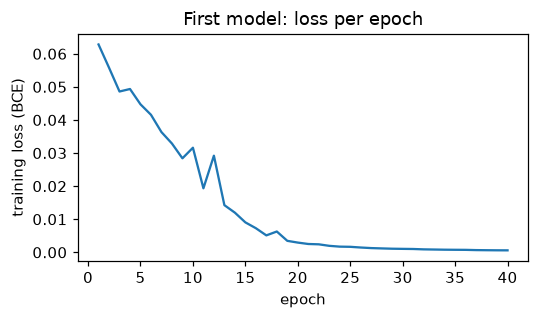

training-set F1 (optimistic - same data it was fitted on): 1.000


In [9]:
first_model = NeuralNetwork(hidden_layers=(32,), activation="relu", learning_rate=2.0, epochs=40,
                            batch_size=32, seed=SEED)
t0 = time.perf_counter()
first_model.fit(X_train, y_train)
print(first_model)
print(f"trainable parameters: {first_model.n_parameters_:,}   fit time: {time.perf_counter() - t0:.1f}s")

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(range(1, len(first_model.loss_history_) + 1), first_model.loss_history_)
ax.set_xlabel("epoch"); ax.set_ylabel("training loss (BCE)"); ax.set_title("First model: loss per epoch")
plt.tight_layout(); plt.show()

train_pred = first_model.predict(X_train)
print(f"training-set F1 (optimistic - same data it was fitted on): {f1_score(y_train, train_pred):.3f}")

## Part 4 — Training with different hyperparameters

### How we compare configurations without touching the test set

Tuning needs data the model has not been trained on, but the assignment forbids re-splitting the given files.
So every configuration is scored with **stratified 5-fold cross-validation inside the training set**
(`src/cv.py`): the 957 training messages are dealt into 5 folds with the same spam share; in turn each fold is
held out, the feature pipeline **and** the network are fitted on the other four, and the held-out fold is
scored. We report the mean and standard deviation of the Spam-class F1 over the 5 folds. The test set stays
sealed until Part 5.

### The grid

We start from a reference configuration — one hidden layer of 32 ReLU units, learning rate 2.0, 40 epochs,
batch size 32, TF-IDF + handcrafted features — and vary one knob at a time, plus a few combinations
(12 configurations; the whole run takes well under a minute). The learning-rate centre came from a quick
calibration run on the training set (CV F1 0.90 at 0.1, 0.93 at 0.5, 0.94 at 2.0 for the reference
architecture) — TF-IDF rows have unit norm, so the gradients are small and unusually large step sizes are
normal.

| knob | values tried | question it answers |
|---|---|---|
| `hidden_layers` | `()` = logistic regression, `(32,)`, `(64, 32)` | does depth help over a linear model? |
| `learning_rate` | 0.5, 2.0, 8.0 | is SGD stable and fast enough? |
| `activation` | relu, tanh | does the non-linearity matter? |
| `class_weight` | None, "balanced" | does up-weighting the rare spam class help F1? |
| `use_extra` | False, True | do the 7 handcrafted cues add anything to TF-IDF? |
| `l2`, `batch_size` | 0 vs 1e-3, 32 vs 8 | regularisation and noisier gradients |

In [10]:
LR_MID = 2.0          # centre of the learning-rate grid (from the calibration run described above)

def config(name, hidden=(32,), activation="relu", lr=LR_MID, class_weight=None, use_extra=True, l2=0.0, batch_size=32):
    return {"name": name,
            "features": {"max_features": 2000, "min_df": 2, "use_extra": use_extra},
            "model": {"hidden_layers": hidden, "activation": activation, "learning_rate": lr, "epochs": 40,
                      "batch_size": batch_size, "l2": l2, "class_weight": class_weight, "seed": SEED}}

configs = [
    config("logreg / tfidf only",             hidden=(), use_extra=False),
    config("logreg / +extra",                 hidden=()),
    config("mlp32 / tfidf only",              use_extra=False),
    config("mlp32 / +extra  (reference)"),
    config("mlp32 / +extra / balanced",       class_weight="balanced"),
    config("mlp32 / +extra / tanh",           activation="tanh"),
    config("mlp32 / +extra / lr 0.5",         lr=LR_MID / 4),
    config("mlp32 / +extra / lr 8.0",         lr=LR_MID * 4),
    config("mlp32 / +extra / l2=1e-3",        l2=1e-3),
    config("mlp32 / +extra / batch 8",        batch_size=8),
    config("mlp64-32 / +extra",               hidden=(64, 32)),
    config("mlp64-32 / +extra / balanced",    hidden=(64, 32), class_weight="balanced"),
]

t0 = time.perf_counter()
results = run_grid(train_texts, y_train, configs, k=5, seed=SEED)
print(f"\ntotal: {time.perf_counter() - t0:.0f}s")

logreg / tfidf only                F1 = 0.897 +/- 0.041   P = 0.949  R = 0.853   (0.4s)


logreg / +extra                    F1 = 0.918 +/- 0.037   P = 0.964  R = 0.878   (0.6s)


mlp32 / tfidf only                 F1 = 0.905 +/- 0.048   P = 0.949  R = 0.870   (1.3s)


mlp32 / +extra  (reference)        F1 = 0.941 +/- 0.025   P = 0.959  R = 0.927   (1.5s)


mlp32 / +extra / balanced          F1 = 0.933 +/- 0.037   P = 0.945  R = 0.927   (1.5s)


...

mlp32 / +extra / lr 8.0            F1 = 0.915 +/- 0.023   P = 0.909  R = 0.927   (1.5s)


mlp32 / +extra / l2=1e-3           F1 = 0.922 +/- 0.027   P = 0.928  R = 0.919   (1.6s)


mlp32 / +extra / batch 8           F1 = 0.912 +/- 0.032   P = 0.927  R = 0.903   (2.8s)


mlp64-32 / +extra                  F1 = 0.942 +/- 0.025   P = 0.952  R = 0.935   (2.3s)


mlp64-32 / +extra / balanced       F1 = 0.092 +/- 0.113   P = 0.052  R = 0.400   (0.8s)

total: 18s


,name,hidden_layers,activation,learning_rate,class_weight,use_extra,l2,batch_size,f1_mean,f1_std,precision_mean,recall_mean,diverged_folds,seconds
0,mlp64-32 / +extra,"(64, 32)",relu,2.0,NaN,True,0.000,32,0.942,0.025,0.952,0.935,0,2.3
1,mlp32 / +extra (reference),"(32,)",relu,2.0,NaN,True,0.000,32,0.941,0.025,0.959,0.927,0,1.5
2,mlp32 / +extra / balanced,"(32,)",relu,2.0,balanced,True,0.000,32,0.933,0.037,0.945,0.927,0,1.5
3,mlp32 / +extra / tanh,"(32,)",tanh,2.0,NaN,True,0.000,32,0.932,0.033,0.952,0.919,0,1.7
4,mlp32 / +extra / lr 0.5,"(32,)",relu,0.5,NaN,True,0.000,32,0.929,0.032,0.950,0.911,0,1.5
5,mlp32 / +extra / l2=1e-3,"(32,)",relu,2.0,NaN,True,0.001,32,0.922,0.027,0.928,0.919,0,1.6
6,logreg / +extra,(),relu,2.0,NaN,True,0.000,32,0.918,0.037,0.964,0.878,0,0.6
7,mlp32 / +extra / lr 8.0,"(32,)",relu,8.0,NaN,True,0.000,32,0.915,0.023,0.909,0.927,0,1.5
8,mlp32 / +extra / batch 8,"(32,)",relu,2.0,NaN,True,0.000,8,0.912,0.032,0.927,0.903,0,2.8
9,mlp32 / tfidf only,"(32,)",relu,2.0,NaN,False,0.000,32,0.905,0.048,0.949,0.870,0,1.3


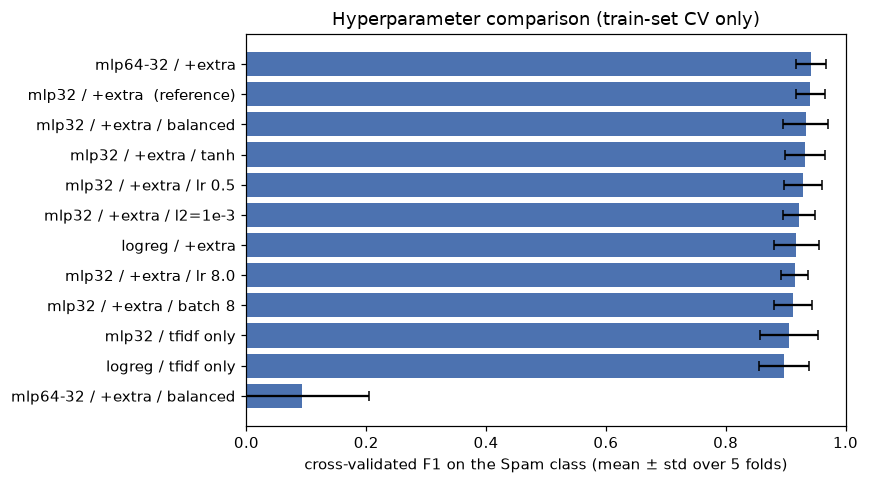

In [11]:
table = results[["name", "hidden_layers", "activation", "learning_rate", "class_weight", "use_extra", "l2",
                 "batch_size", "f1_mean", "f1_std", "precision_mean", "recall_mean", "diverged_folds", "seconds"]].copy()
for col in ["f1_mean", "f1_std", "precision_mean", "recall_mean"]:
    table[col] = table[col].round(3)
table["seconds"] = table["seconds"].round(1)
display(table)

fig, ax = plt.subplots(figsize=(8, 4.5))
order = results.iloc[::-1]
ax.barh(order["name"], order["f1_mean"], xerr=order["f1_std"], color="#4C72B0", capsize=3)
ax.set_xlabel("cross-validated F1 on the Spam class (mean ± std over 5 folds)")
ax.set_xlim(max(0.0, float(order["f1_mean"].min()) - 0.15), 1.0)
ax.set_title("Hyperparameter comparison (train-set CV only)")
plt.tight_layout(); plt.show()

### Choosing the winning configuration

With 957 training messages the fold-to-fold standard deviation of F1 is about 0.03, so configurations that
differ by a few thousandths are **not distinguishable** — picking the raw maximum would just be picking noise.
We therefore use the standard **one-standard-error rule**: take the best mean F1, compute its standard error
(std / √5), and among all configurations within one standard error of the best choose the **simplest** one
(fewest hidden units; ties broken by mean F1). Simpler models are cheaper, easier to explain, and less likely
to have won by chance.

In [12]:
K_FOLDS = 5
top = results.iloc[0]
one_se = top["f1_std"] / np.sqrt(K_FOLDS)
candidates = results[results["f1_mean"] >= top["f1_mean"] - one_se].copy()
candidates["hidden_units"] = candidates["hidden_layers"].apply(sum)
candidates = candidates.sort_values(["hidden_units", "f1_mean"], ascending=[True, False], kind="stable")
print(f"best mean F1 = {top['f1_mean']:.3f} ({top['name']});  one standard error = {one_se:.3f};  "
      f"threshold = {top['f1_mean'] - one_se:.3f}")
print("configurations within one standard error of the best, simplest first:")
display(candidates[["name", "hidden_layers", "hidden_units", "f1_mean", "f1_std", "precision_mean", "recall_mean"]].round(3))

best = candidates.iloc[0]
best_cfg = next(c for c in configs if c["name"] == best["name"])
print("WINNER:", best["name"])
print("  CV F1 = %.3f ± %.3f   precision = %.3f   recall = %.3f" % (best["f1_mean"], best["f1_std"], best["precision_mean"], best["recall_mean"]))
print("  features:", best_cfg["features"])
print("  model   :", best_cfg["model"])

best mean F1 = 0.942 (mlp64-32 / +extra);  one standard error = 0.011;  threshold = 0.931
configurations within one standard error of the best, simplest first:


,name,hidden_layers,hidden_units,f1_mean,f1_std,precision_mean,recall_mean
1,mlp32 / +extra (reference),"(32,)",32,0.941,0.025,0.959,0.927
2,mlp32 / +extra / balanced,"(32,)",32,0.933,0.037,0.945,0.927
3,mlp32 / +extra / tanh,"(32,)",32,0.932,0.033,0.952,0.919
0,mlp64-32 / +extra,"(64, 32)",96,0.942,0.025,0.952,0.935


WINNER: mlp32 / +extra  (reference)
  CV F1 = 0.941 ± 0.025   precision = 0.959   recall = 0.927
  features: {'max_features': 2000, 'min_df': 2, 'use_extra': True}
  model   : {'hidden_layers': (32,), 'activation': 'relu', 'learning_rate': 2.0, 'epochs': 40, 'batch_size': 32, 'l2': 0.0, 'class_weight': None, 'seed': 42}


**What the grid tells us** (all numbers are 5-fold CV F1 on the Spam class, inside the training set):

* **The handcrafted cues are the single most useful change.** They lift logistic regression from 0.897 to
  0.918 and the 32-unit network from 0.905 to 0.941, almost entirely through recall (0.870 → 0.927 for the
  network): length, digit count, currency and phone/URL flags catch spam whose *words* are unremarkable.
* **One hidden layer helps, a second does not.** With the same features the network beats logistic regression
  by 0.023 (0.918 → 0.941), again through recall — the non-linearity lets it combine cues ("long *and* has a
  phone number") that a linear model can only add up. Going deeper (64-32 units, three times the parameters)
  adds 0.001, i.e. nothing measurable.
* **Learning rate** is the classic U-shape: 0.5 is too slow for 40 epochs (0.929), 2.0 is best (0.941), 8.0
  starts to thrash (0.915, precision drops to 0.909).
* **`class_weight="balanced"`** did not pay off. For the 32-unit network it left recall unchanged and cost
  precision (0.933). For the deeper network it made SGD **diverge in 4 of 5 folds**: weighting the spam rows
  ×6.8 multiplies their gradient, which at learning rate 2.0 is enough to blow the weights up — a useful
  reminder that class weights and the learning rate are not independent knobs.
* `tanh` vs `relu` (0.932 vs 0.941), L2 = 1e-3 (0.922) and batch size 8 (0.912) are all within noise or
  slightly worse; none earns its extra complexity.

**Decision.** The best mean F1 is 0.942 (`mlp64-32 / +extra`) with a standard error of 0.011, so every
configuration above 0.931 is statistically tied with it: the reference `mlp32 / +extra` (0.941), its
`balanced` (0.933) and `tanh` (0.932) variants, and the deeper network itself. Among the tied
configurations the one-standard-error rule picks the simplest — 32 hidden units — and, within those, the
highest F1: **`mlp32 / +extra`: one hidden layer of 32 ReLU units, learning rate 2.0, 40 epochs, batch
size 32, no L2, no class weighting, TF-IDF (1 142 tokens) + 7 handcrafted features.** This choice was
fixed here, before the test set was opened; the runner-up is *not* evaluated on the test set, so the
number reported in Part 5 is a clean estimate for the single model we committed to.

### The winning flow on 2–3 training examples

The same three training messages as in Part 2, now passed through the winning feature configuration and
scored by a model trained with the winning hyperparameters on **all** training data — this is the model
that goes to the test set in Part 5.

In [13]:
best_pipe = FeaturePipeline(**best_cfg["features"]).fit(train_texts)
best_model = NeuralNetwork(**best_cfg["model"]).fit(best_pipe.transform(train_texts), y_train)

def show_flow(texts, labels, pipeline, model):
    for text, label in zip(texts, labels):
        vec = pipeline.transform([text])
        p = float(model.predict_proba(vec)[0])
        print("-" * 100)
        print(f"[{LABEL_NAMES[int(label)]}]  {text}")
        print("  tokens     :", tokenize(text))
        print("  top tf-idf :", [(t, round(w, 3)) for t, w in pipeline.tfidf_.explain(text, k=5)])
        if pipeline.use_extra:
            print("  handcrafted:", {n: round(float(v), 1) for n, v in zip(HANDCRAFTED_NAMES, handcrafted_features([text])[0])})
        print(f"  -> {vec.shape[1]} features -> P(spam) = {p:.3f} -> predicted {LABEL_NAMES[int(p >= 0.5)]}")

show_flow([train_texts[i] for i in train_examples], y_train[train_examples], best_pipe, best_model)

----------------------------------------------------------------------------------------------------
[Spam]  This is the 2nd time we have tried 2 contact u. U have won the £750 Pound prize. 2 claim is easy, call 087187272008 NOW1! Only 10p per minute. BT-national-rate.
  tokens     : ['this', 'is', 'the', '__num__', 'nd', 'time', 'we', 'have', 'tried', '__num__', 'contact', 'have', 'won', 'the', '__num__', 'pound', 'prize', '__num__', 'claim', 'is', 'easy', 'call', '__phone__', 'now', '__num__', 'only', '__num__', 'per', 'minute', 'bt', 'national', 'rate']
  top tf-idf : [('__num__', 0.486), ('have', 0.233), ('pound', 0.232), ('minute', 0.222), ('national', 0.222)]
  handcrafted: {'n_chars': 160.0, 'n_words': 30.0, 'n_digits': 21.0, 'upper_ratio': 0.1, 'n_exclaim': 1.0, 'has_currency': 1.0, 'has_url_or_phone': 1.0}
  -> 1149 features -> P(spam) = 1.000 -> predicted Spam
----------------------------------------------------------------------------------------------------
[Spam]  SMS SERV

## Part 5 — Prediction and evaluation on the test set

Now — and only now — the test set is used for evaluation. The winning pipeline and model from Part 4 were
fitted on the **whole training set**; here they are merely *applied* to `SMS_test.csv`. Nothing is re-fitted.

In [14]:
X_test = best_pipe.transform(test_texts)
test_proba = best_model.predict_proba(X_test)
test_pred = (test_proba >= 0.5).astype(int)
print(f"test feature matrix: {X_test.shape}   predicted spam: {int(test_pred.sum())} of {len(test_pred)}")

test feature matrix: (125, 1149)   predicted spam: 70 of 125


### The flow on 2–3 test messages

The same three test messages as in Part 2, through the winning pipeline and model.

In [15]:
show_flow([test_texts[i] for i in test_examples], y_test[test_examples], best_pipe, best_model)

----------------------------------------------------------------------------------------------------
[Spam]  Loan for any purpose £500 - £75,000. Homeowners + Tenants welcome. Have you been previously refused? We can still help. Call Free 0800 1956669 or text back 'help'
  tokens     : ['loan', 'for', 'any', 'purpose', '__num__', '__num__', 'homeowners', 'tenants', 'welcome', 'have', 'you', 'been', 'previously', 'refused', 'we', 'can', 'still', 'help', 'call', 'free', '__phone__', 'or', 'text', 'back', 'help']
  top tf-idf : [('help', 0.541), ('welcome', 0.335), ('any', 0.246), ('been', 0.246), ('text', 0.234)]
  handcrafted: {'n_chars': 162.0, 'n_words': 28.0, 'n_digits': 19.0, 'upper_ratio': 0.1, 'n_exclaim': 0.0, 'has_currency': 1.0, 'has_url_or_phone': 1.0}
  -> 1149 features -> P(spam) = 1.000 -> predicted Spam
----------------------------------------------------------------------------------------------------
[Non-Spam]  Y de asking like this.
  tokens     : ['de', 'asking', 'lik

### The first 5 test predictions

In [16]:
first5 = pd.DataFrame({
    "message": [t[:90] + ("…" if len(t) > 90 else "") for t in test_texts[:5]],
    "true label": [LABEL_NAMES[int(v)] for v in y_test[:5]],
    "P(spam)": np.round(test_proba[:5], 3),
    "predicted": [LABEL_NAMES[int(v)] for v in test_pred[:5]],
})
first5

,message,true label,P(spam),predicted
0,"UpgrdCentre Orange customer, you may now claim your FREE CAMERA PHONE upgrade for your loy…",Spam,1.0,Spam
1,"Loan for any purpose £500 - £75,000. Homeowners + Tenants welcome. Have you been previousl…",Spam,1.0,Spam
2,Congrats! Nokia 3650 video camera phone is your Call 09066382422 Calls cost 150ppm Ave cal…,Spam,1.0,Spam
3,URGENT! Your Mobile number has been awarded with a £2000 prize GUARANTEED. Call 0905809445…,Spam,1.0,Spam
4,Someone has contacted our dating service and entered your phone because they fancy you! To…,Spam,1.0,Spam


### Quality on the whole test set

The assignment's metric for a binary problem is the **F1 score of the positive class (Spam)**; precision,
recall, accuracy and the confusion matrix are shown for context.

F1 (Spam)  = 0.945   <- the assignment's quality metric
precision  = 0.986   recall = 0.908   accuracy = 0.936

confusion matrix (rows = true, columns = predicted):


,pred Non-Spam,pred Spam
true Non-Spam,48,1
true Spam,7,69


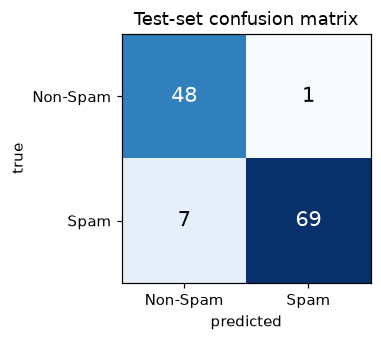

In [17]:
cm = confusion_matrix(y_test, test_pred)
print(f"F1 (Spam)  = {f1_score(y_test, test_pred):.3f}   <- the assignment's quality metric")
print(f"precision  = {precision(y_test, test_pred):.3f}   recall = {recall(y_test, test_pred):.3f}   accuracy = {accuracy(y_test, test_pred):.3f}")
print("\nconfusion matrix (rows = true, columns = predicted):")
display(pd.DataFrame(cm, index=["true Non-Spam", "true Spam"], columns=["pred Non-Spam", "pred Spam"]))

fig, ax = plt.subplots(figsize=(3.6, 3.2))
ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center", color="white" if v > cm.max() / 2 else "black", fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Non-Spam", "Spam"]); ax.set_yticks([0, 1]); ax.set_yticklabels(["Non-Spam", "Spam"])
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Test-set confusion matrix")
plt.tight_layout(); plt.show()

### Where does the model fail?

In [18]:
errors = pd.DataFrame({
    "message": test_texts, "true": [LABEL_NAMES[int(v)] for v in y_test],
    "P(spam)": np.round(test_proba, 3), "predicted": [LABEL_NAMES[int(v)] for v in test_pred],
})
errors = errors[errors["true"] != errors["predicted"]]
print(f"{len(errors)} misclassified test messages out of {len(test_texts)}")
pd.set_option("display.max_colwidth", 170)
display(errors)

train_set = set(train_texts)
overlap = [i for i, t in enumerate(test_texts) if t in train_set]
print(f"\nnote: {len(overlap)} test messages also occur verbatim in the training file (kept - the files are used as shipped); "
      f"{int((test_pred[overlap] == y_test[overlap]).sum())} of them are classified correctly")

8 misclassified test messages out of 125


,message,true,P(spam),predicted
25,Ringtone Club: Get the UK singles chart on your mobile each week and choose any top quality ringtone! This message is free of charge.,Spam,0.172,Non-Spam
32,"Will u meet ur dream partner soon? Is ur career off 2 a flyng start? 2 find out free, txt HORO followed by ur star sign, e. g. HORO ARIES",Spam,0.010,Non-Spam
37,"BangBabes Ur order is on the way. U SHOULD receive a Service Msg 2 download UR content. If U do not, GoTo wap. bangb. tv on UR mobile internet/service menu",Spam,0.016,Non-Spam
51,"Did you hear about the new ""Divorce Barbie""? It comes with all of Ken's stuff!",Spam,0.001,Non-Spam
55,SMS. ac Sptv: The New Jersey Devils and the Detroit Red Wings play Ice Hockey. Correct or Incorrect? End? Reply END SPTV,Spam,0.022,Non-Spam
57,Thanks for your subscription to Ringtone UK your mobile will be charged £5/month Please confirm by replying YES or NO. If you reply NO you will not be charged,Spam,0.179,Non-Spam
64,"FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, £1.50 to rcv",Spam,0.068,Non-Spam
120,"7 wonders in My WORLD 7th You 6th Ur style 5th Ur smile 4th Ur Personality 3rd Ur Nature 2nd Ur SMS and 1st ""Ur Lovely Friendship""... good morning dear",Non-Spam,0.613,Spam



note: 5 test messages also occur verbatim in the training file (kept - the files are used as shipped); 5 of them are classified correctly


### Discussion

**Headline.** On the 125 test messages the chosen model reaches **F1 = 0.945** on the Spam class
(precision 0.986, recall 0.908, accuracy 0.936). It flagged 70 messages as spam; 69 of them were spam and it
missed 7. This is right in line with the cross-validated estimate from Part 4 (0.941 ± 0.025), so model
selection did not overfit the training set.

**Where it fails — the 7 missed spam messages (false negatives).** They share one property: they lack the
"hard" spam signals the model leans on most — a phone number, a URL, a currency amount, a *win/claim/prize*
vocabulary — and instead read like personal texts:

* *Subscription / content-service spam with no call to action:* "Ringtone Club: Get the UK singles chart…"
  (P(spam) = 0.17), "Thanks for your subscription to Ringtone UK… £5/month… reply YES or NO" (0.18),
  "SMS. ac Sptv: … Correct or Incorrect? Reply END SPTV" (0.02). Words like *ringtone*, *subscription*,
  *reply* are too rare among the 122 training spam messages to have learned strong weights.
* *Spam written in the same abbreviations as personal messages:* "Will u meet ur dream partner soon?… txt
  HORO" (0.01), "BangBabes Ur order is on the way… GoTo wap. bangb. tv" (0.02), "FreeMsg Hey there
  darling…" (0.07). The *u / ur / 2* style is typical of the hams in this corpus, and in the BangBabes
  message the link is broken up by spaces ("wap. bangb. tv"), so the URL detector never fires.
* *Probable label noise:* "Did you hear about the new 'Divorce Barbie'? It comes with all of Ken's stuff!"
  (0.001) is a joke between friends. It is labelled Spam in the file, but no reasonable classifier would —
  or should — flag it.

**The one false alarm.** "7 wonders in My WORLD 7th You 6th Ur style 5th Ur smile… good morning dear"
(P(spam) = 0.61, a borderline call) is a chain/forward message: long, seven ordinal numbers that all become
`__num__`, capitalised words — precisely the *style* cues that make spam recognisable. The model is right
that it looks like broadcast content; the dataset happens to label it as a personal message.

**Pattern.** The classifier is very *precise* (1 false alarm in 49 legitimate messages) and its misses are
concentrated in spam that imitates personal texting. That is the expected behaviour of a bag-of-words model
with style features trained on 957 messages, and it is the safer failure mode for a spam filter — hiding a
real message costs the user more than letting one advertisement through.

**Context that qualifies these numbers.**

1. *Distribution shift.* The training file is 12.7 % spam, the test file 60.8 %. F1 on the Spam class is the
   right summary either way, but accuracy is not comparable between the two, and the high spam share makes
   test precision look a little better than it would on a realistic inbox (fewer legitimate messages means
   fewer chances for a false alarm).
2. *Overlap.* 5 of the 125 test messages also appear verbatim in the training file (3 spam, 2 ham). They are
   all classified correctly; without them the test F1 would be 0.943 — essentially unchanged.
3. *Small test set.* With 76 spam messages, every missed one moves recall by 1.3 points and F1 by roughly
   0.7 points. The honest reading is "F1 somewhere around 0.94 ± 0.04", not "0.945".

**What we would try next** (all tuned with cross-validation, never on the test set): a lower decision
threshold — precision is 0.986, so there is room to trade some of it for recall (two of the misses have
P(spam) ≈ 0.17–0.18); normalising SMS slang (*u → you, ur → your*) and character n-grams, so that spam in
texting style is not mistaken for a friend; a URL detector tolerant of spaces around dots; and simply more
training spam — 122 examples is not much to learn "ringtone subscription" from.